# Downloading and Prepping data for Projecting Monthly Bat Speed 

This file
- Aggregates monthly data over each player season
- Clean data for downstream modeling
- Visualizes exit velocity and bat speed monthly data

Much like any modeling project, we need data. This file explains my steps for pulling statcast data, transforming it, and visualizations some relationships.

## Preparing the data

In [1]:
import pandas as pd
import numpy as np

from matplotlib import gridspec
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)

pandas: 3.0.1
numpy: 2.4.3


Since our plan is to use a player's 90th percentile Exit Velocity to help "back-impute" a player's bat speed, we aggregate each player's monthly 90th percentile exit velocity (EV90).

In [2]:
data = pd.read_csv('agg_data.csv')
data['month_name'] = pd.Categorical(data['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,month_number,year,month_name,is_swing
0,FF,2016-10-02,96.4,-0.53,6.23,"Osuna, Roberto",598265,532077,field_out,hit_into_play,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,1
1,FF,2016-10-02,96.8,-0.35,6.34,"Osuna, Roberto",598265,532077,NaN,called_strike,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0
2,SI,2016-10-02,96.7,-0.56,6.22,"Osuna, Roberto",593428,532077,single,hit_into_play,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,1
3,FF,2016-10-02,97.0,-0.48,6.28,"Osuna, Roberto",593428,532077,NaN,called_strike,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0
4,FF,2016-10-02,93.6,-0.54,6.23,"Osuna, Roberto",593428,532077,NaN,ball,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0


In [3]:
player_bio = pd.read_csv('player_bio.csv')
player_bio.head()

,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
0,598265,Jackie Bradley Jr.,Jackie,Bradley Jr.,L,CF,1990-04-19,Richmond,VA,USA
1,593428,Xander Bogaerts,Xander,Bogaerts,R,SS,1992-10-01,Oranjestad,NaN,Aruba
2,434670,Hanley Ramirez,Hanley,Ramirez,R,SS,1983-12-23,Samana,NaN,Dominican Republic
3,120074,David Ortiz,David,Ortiz,L,DH,1975-11-18,Santo Domingo,NaN,DOM
4,605141,Mookie Betts,Mookie,Betts,R,SS,1992-10-07,Nashville,TN,USA


In [4]:
pop = data.groupby(['batter','month_name','year']).agg(
        obs = ('pitch_type','count'),
        swings_hand = ('is_swing', 'sum')
    ).reset_index()

# filter to only balls in play for exit velocity data
evd = data.loc[data['description']=='hit_into_play'].reset_index(drop=True)
# filter out bunts
evd['des'] = evd['des'].str.lower()
evd = evd.loc[~evd['des'].str.contains('bunt', na=False)].reset_index(drop=True)
# filter on exit velocity exists
evd = evd.loc[~evd['launch_speed'].isna()].reset_index(drop=True)
# filter out ev above 123
evd = evd.loc[evd['launch_speed']<123].reset_index(drop=True)

# calc 90th percentile exit velo
top90 = evd.groupby([
    'batter','month_name','year'
    ]).agg(
        ev90=('launch_speed', lambda x: np.percentile(x, 90)),
        ev50=('launch_speed', lambda x: np.percentile(x, 50)),
        ev_avg=('launch_speed', lambda x: np.mean(x)),
        bips=('launch_speed', 'count')
    ).reset_index()

In [5]:
top90.head(10)

,batter,month_name,year,ev90,ev50,ev_avg,bips
0,112526,Mar/Apr,2016,83.87,82.15,82.150000,2
1,112526,Mar/Apr,2017,82.90,82.90,82.900000,1
2,112526,May,2016,94.61,85.45,85.450000,2
3,112526,May,2017,88.51,78.15,78.150000,2
4,112526,Jun,2016,107.39,103.35,103.350000,2
5,112526,Jun,2017,74.20,74.20,74.200000,1
6,112526,Jun,2018,76.90,76.90,76.900000,1
7,112526,Jul,2016,84.54,78.30,79.966667,3
8,112526,Aug,2016,96.20,84.30,80.033333,6
9,112526,Aug,2017,80.44,77.40,77.400000,2


In [6]:
top90.loc[(top90['batter']==405395)&(top90['year']<=2023)]['year'].max()

np.int64(2022)

In [7]:
top90['ev90'].describe(percentiles=[.005, .01, .05, .1, .25, .5, .75, .95])

count    32564.000000
mean       100.884300
std          7.238344
min         25.500000
0.5%        65.300000
1%          71.400000
5%          86.691500
10%         93.500000
25%         99.260000
50%        102.420000
75%        104.960000
95%        108.228500
max        118.800000
Name: ev90, dtype: float64

<Axes: >

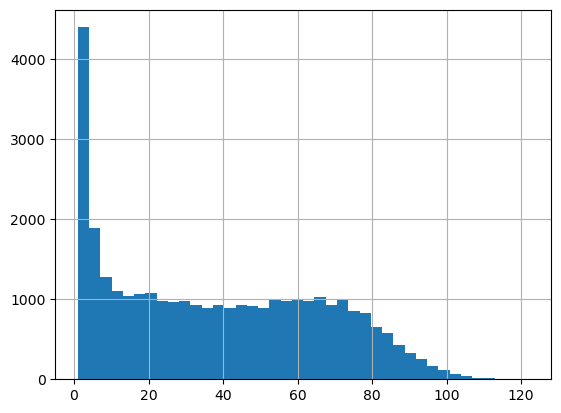

In [8]:
# remove observations where ev90<65
top90['bips'] = np.where(top90['ev90']<65, np.nan, top90['bips'])
top90['ev90'] = np.where(top90['ev90']<65, np.nan, top90['ev90'])

# plot a histogram of balls in play (BIPs)
top90['bips'].hist(bins=40)

With the histogram, we see there are many month observations with fewer than 5 bips. In these months, a player's observed EV90 is not a reflection of their true talent.

In [9]:
# conditional on 90th percentile ev, compute avg pitch velo faced
top = evd.merge(top90, how='left', on=['batter','month_name','year'])
top = top.loc[top['launch_speed'] >= top['ev90']].reset_index(drop=True)
top = top.groupby(['batter','month_name','year']).agg(
        avg_pitch_velocity=('release_speed', 'mean'),
        bips_hard=('launch_speed', 'count')
).reset_index()

top90 = top90.merge(top, on=['batter','month_name','year'], how='left')
pop = pop.merge(top90, on=['batter','month_name','year'], how='left')

Before we continue, let's peak at our data to confirm everything is in proper order. We should have a batter column with the ID of the player, month_name, year, and then some batted ball data

In [10]:
pop.head()

,batter,month_name,year,obs,swings_hand,ev90,ev50,ev_avg,bips,avg_pitch_velocity,bips_hard
0,112526,Mar/Apr,2016,20,13,83.87,82.15,82.15,2.0,94.2,1.0
1,112526,Mar/Apr,2017,30,16,82.90,82.90,82.90,1.0,92.5,1.0
2,112526,May,2016,46,15,94.61,85.45,85.45,2.0,90.5,1.0
3,112526,May,2017,14,8,88.51,78.15,78.15,2.0,91.2,1.0
4,112526,Jun,2016,35,21,107.39,103.35,103.35,2.0,86.9,1.0


In [11]:
pop.loc[(pop['batter']==405395)&(pop['year']<=2023)]['year'].max()

np.int64(2022)

In [12]:
# Now we compile Bat Speed data and merge onto the exit velocity dataframe
batspeed_data = data.loc[~data['bat_speed'].isna()].reset_index(drop=True)
bsd = batspeed_data.groupby([
    'batter','month_name','year'
    ]).agg(
        bat_speed =('bat_speed', 'mean'),
        bat_speed_sd =('bat_speed', 'std'),
        bat_speed_50 =('bat_speed', lambda x: np.percentile(x, 50)),
        swings=('bat_speed', 'count')
    ).reset_index()
pop = pop.merge(bsd, on=['batter','month_name','year'], how='left')

# merging the bio data onto the count data
df = pop.merge(player_bio, left_on=['batter'], right_on=['bam_id'], how='left')
df.tail()

,batter,month_name,year,obs,swings_hand,ev90,ev50,ev_avg,bips,avg_pitch_velocity,...,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
33978,823550,Jun,2026,157,65,103.09,81.40,83.466667,24.0,96.133333,...,823550,Sung-Mun Song,Sung-Mun,Song,L,2B,1996-08-29,Seoul,NaN,Republic of Korea
33979,823550,Jul,2026,183,81,101.53,90.10,89.420588,34.0,90.750000,...,823550,Sung-Mun Song,Sung-Mun,Song,L,2B,1996-08-29,Seoul,NaN,Republic of Korea
33980,823550,Aug,2026,88,36,96.60,83.90,85.572727,11.0,96.600000,...,823550,Sung-Mun Song,Sung-Mun,Song,L,2B,1996-08-29,Seoul,NaN,Republic of Korea
33981,828599,Jul,2026,157,79,106.69,91.95,92.727273,22.0,91.200000,...,828599,Lucas Spence,Lucas,Spence,L,CF,2003-01-27,Chicago Heights,IL,USA
33982,829272,Aug,2025,3,0,NaN,NaN,NaN,NaN,NaN,...,829272,Shinnosuke Ogasawara,Shinnosuke,Ogasawara,L,P,1997-10-08,Fujisawa,NaN,Japan


In [13]:
df.loc[(df['batter']==405395)&(df['year']<=2023)]['year'].max()

np.int64(2022)

In [14]:
# swings should always be more than bips
assert(len(df.loc[df['swings_hand']<df['bips']]) == 0)

In [15]:
# swings can be equal to bips, but rare
df.loc[(df['swings_hand']==df['bips'])&df['swings'].isnull()][['batter','month_name','year','obs','swings_hand','bips']]

,batter,month_name,year,obs,swings_hand,bips
229,407908,Jun,2016,4,1,1.0
369,425532,Aug,2016,1,1,1.0
478,425794,Sep/Oct,2017,4,1,1.0
651,429719,Jul,2018,3,2,2.0
724,430912,Jun,2016,1,1,1.0
...,...,...,...,...,...,...
30877,676840,Mar/Apr,2021,1,1,1.0
31056,677651,Sep/Oct,2021,5,2,2.0
31171,677960,Sep/Oct,2021,4,2,2.0
32498,686469,Jun,2022,24,5,5.0


In [16]:
# spot check a few players
data.loc[(data['batter']==461865)&(data['month_name']=='Jul')&(data['year']==2021)][['game_date','description','launch_speed','is_swing']]

,game_date,description,launch_speed,is_swing
3417628,2021-07-31,hit_into_play,70.3,1
3417665,2021-07-31,hit_into_play,94.9,1
3417666,2021-07-31,ball,NaN,0
3417717,2021-07-31,hit_into_play,95.6,1
3417718,2021-07-31,ball,NaN,0
3417719,2021-07-31,ball,NaN,0
3417781,2021-07-31,hit_into_play,99.5,1


In [17]:
# spot check a few players
data.loc[(data['batter']==686469)&(data['month_name']=='Jun')&(data['year']==2022)][['game_date','description','launch_speed','is_swing']]

,game_date,description,launch_speed,is_swing
4256507,2022-06-29,ball,NaN,0
4256508,2022-06-29,ball,NaN,0
4256509,2022-06-29,ball,NaN,0
4256510,2022-06-29,ball,NaN,0
4256578,2022-06-29,hit_into_play,103.8,1
4256579,2022-06-29,ball,NaN,0
4256580,2022-06-29,ball,NaN,0
4256650,2022-06-29,ball,NaN,0
4256651,2022-06-29,blocked_ball,NaN,0
4256652,2022-06-29,called_strike,NaN,0


In [18]:
# spot check a few players
data.loc[(data['batter']==677651)&(data['month_name']=='Sep/Oct')&(data['year']==2021)][['game_date','description','launch_speed','is_swing']]

,game_date,description,launch_speed,is_swing
3275527,2021-09-05,hit_into_play,91.5,1
3275528,2021-09-05,ball,NaN,0
3275529,2021-09-05,called_strike,NaN,0
3275586,2021-09-05,hit_into_play,76.1,1
3275587,2021-09-05,called_strike,NaN,0


In [19]:
# validate instances when we have observed swings
df.loc[(df['swings_hand']==df['bips'])&df['swings'].notnull()][['batter','month_name','year','obs','swings_hand','bips','swings']]

,batter,month_name,year,obs,swings_hand,bips,swings
8318,543305,Aug,2023,9,3,3.0,2.0
10681,571657,Jul,2026,2,1,1.0,1.0
24563,657061,Sep/Oct,2023,5,1,1.0,1.0
24605,657088,Mar/Apr,2024,1,1,1.0,1.0
25009,660636,Jul,2023,2,1,1.0,1.0
26073,663967,Jul,2025,1,1,1.0,1.0
26718,664770,Sep/Oct,2023,4,1,1.0,1.0
27930,666624,Aug,2026,14,3,3.0,3.0
28769,669194,Mar/Apr,2025,4,1,1.0,1.0
29022,669288,Sep/Oct,2024,1,1,1.0,1.0


In [20]:
# one instance where swing_hand > observed swings
data.loc[(data['batter']==543305)&(data['month_name']=='Aug')&(data['year']==2023)][['game_date','description','bat_speed']]

,game_date,description,bat_speed
4781235,2023-08-14,hit_into_play,NaN
4781236,2023-08-14,called_strike,NaN
4781237,2023-08-14,called_strike,NaN
4781238,2023-08-14,ball,NaN
4781292,2023-08-14,hit_into_play,67.9
4781338,2023-08-14,hit_into_play,59.8
4781339,2023-08-14,called_strike,NaN
4781340,2023-08-14,ball,NaN
4781341,2023-08-14,called_strike,NaN


In [21]:
# validated swings are calcualted properly. Going to use swings from bat speed (observed swings with bat speed), otherwise swings_hand
df['swing_total'] = np.where(df['swings'].notnull(), df['swings'], df['swings_hand'])
df[['swings','swings_hand','swing_total']].head()

,swings,swings_hand,swing_total
0,NaN,13,13.0
1,NaN,16,16.0
2,NaN,15,15.0
3,NaN,8,8.0
4,NaN,21,21.0


In [22]:
df[['batter','month_name','year','swings','swings_hand','swing_total']].tail()

,batter,month_name,year,swings,swings_hand,swing_total
33978,823550,Jun,2026,58.0,65,58.0
33979,823550,Jul,2026,75.0,81,75.0
33980,823550,Aug,2026,29.0,36,29.0
33981,828599,Jul,2026,74.0,79,74.0
33982,829272,Aug,2025,NaN,0,0.0


In [23]:
# validate a few more final checks
data.loc[(data['batter']==823550)&(data['month_name']=='Jun')&(data['year']==2026)][['game_date','description','bat_speed','is_swing']]

,game_date,description,bat_speed,is_swing
6928471,2026-06-28,hit_into_play,73.9,1
6928472,2026-06-28,ball,NaN,0
6928473,2026-06-28,ball,NaN,0
6928474,2026-06-28,called_strike,NaN,0
6928541,2026-06-28,swinging_strike,72.7,1
...,...,...,...,...
7029273,2026-06-02,foul,64.1,1
7029274,2026-06-02,foul,62.4,1
7029275,2026-06-02,called_strike,NaN,0
7029276,2026-06-02,ball,NaN,0


Some swings do not have a bat speed. Still going to use the swings on record tallied from observed bat speed values as that is where the aggregate is coming from. 

In [24]:
# More transforming and cleaning....

# remove pitchers and encode a few different postitional groupings
df = df.loc[df['position']!='P'].reset_index(drop=True)
df['position'] = np.where(df['position']=='TWP','DH', df['position'])
df['position_group'] = np.where(df['position'].isin(['DH','1B','3B','LF','RF','OF']),'Power','Defense')
df['position_hybrid'] = np.where(df['position'].isin(['LF','RF','OF']),'COF',df['position'])
df['position_hybrid'] = np.where(df['position'].isin(['1B','3B']),'CINF',df['position_hybrid'])
df['position_hybrid'] = np.where(df['position'].isin(['SS','2B','CF']),'UTM',df['position_hybrid'])

# changing columns to floats
for c in ['ev90', 'bips','avg_pitch_velocity', 'bips_hard', 'bat_speed', 'bat_speed_sd','bat_speed_50','swings','age']:
    try:
        df[c] = df[c].astype(float)
    except KeyError:
        continue

# https://www.baseballprospectus.com/news/article/28956/baseball-therapy-the-one-about-exit-velocity/#:~:text=At%2040%2Dsomething%20balls%20in,to%20come%20in%20the%20season.
MIN_BIPS = 40
MIN_SWINGS = 10
# define approx thresholds based on prior studies
df['is_bip_threshold'] = np.where((df['bips']>=MIN_BIPS), 1, 0) # meets threshold
df['is_swing_threshold'] = np.where((df['swing_total']>=MIN_SWINGS), 1, 0) # meets threshold
df['is_ev90_na'] = np.where(df['ev90'].isna(), 1, 0) # have no ev90
df['is_bat_speed_na'] = np.where(df['bat_speed'].isna(), 1, 0) # have no bat speed
# remove the instances with no bips and no bat speed, we cant learn from players that never played
df = df.loc[~((df['is_bat_speed_na']==1) & (df['is_ev90_na']==1))].reset_index(drop=True)

In [25]:
df.loc[(df['batter']==405395)&(df['year']<=2023)]['year'].max()

np.int64(2022)

In [26]:
# count unique players per bucket
posit = df[['batter','position','position_group','position_hybrid']].drop_duplicates(subset=['batter'])
p = posit.groupby(["position_group", "position_hybrid", "position"]).size().reset_index(name="count").sort_values(['position_group',"position_group", "position_hybrid", "position","count"], ascending=False)
q = df['position'].value_counts().reset_index()
p.merge(q, on=['position'])

,position_group,position_hybrid,position,count_x,count_y
0,Power,DH,DH,57,1774
1,Power,COF,RF,179,2844
2,Power,COF,OF,30,314
3,Power,COF,LF,217,3351
4,Power,CINF,3B,182,3213
5,Power,CINF,1B,178,3339
6,Defense,UTM,SS,187,3115
7,Defense,UTM,CF,200,2927
8,Defense,UTM,2B,212,3488
9,Defense,C,C,271,4637


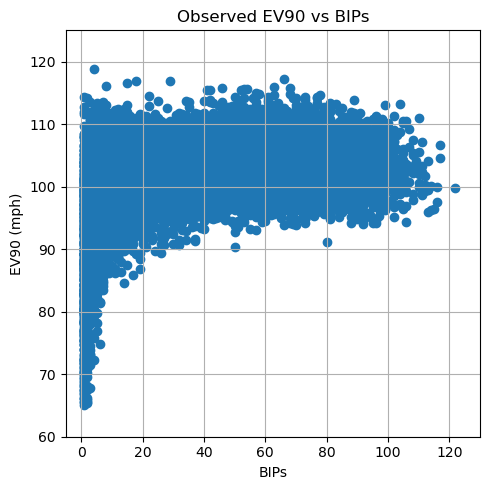

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.scatter(df['bips'], df['ev90'])
ax.set_xlabel('BIPs')
ax.set_ylabel('EV90 (mph)')
ax.set_title('Observed EV90 vs BIPs')
ax.set_xlim(-5, 130)
ax.set_ylim(60, 125)
ax.grid()
plt.tight_layout()

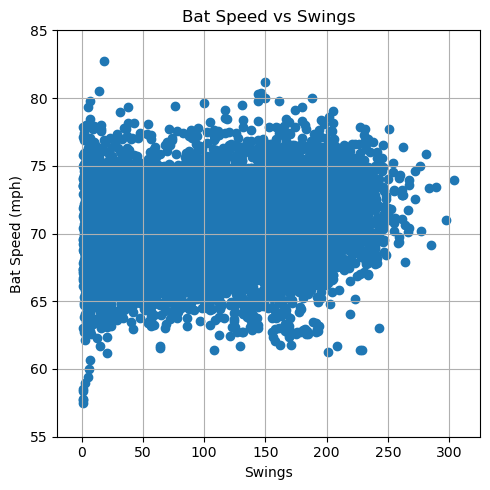

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.scatter(df['swing_total'], df['bat_speed'])
ax.set_xlabel('Swings')
ax.set_ylabel('Bat Speed (mph)')
ax.set_title('Bat Speed vs Swings')
ax.set_xlim(-20, 325)
ax.set_ylim(55, 85)
ax.grid()
plt.tight_layout()

Here we illustrate how noisy EV90 is relative to Bat Speed. A metric can be noisy such that it changes due to sample size. So with the exit velocity data, we see that small samples have a larger variance in the observed monthly data. Bat Speed is less noisy, it takes about 10 swings to stabilize and most player's, even a bench player, should get 10 swings in a month.

Now that we have cleaned and transformed our data, we string it together. For each player, we create a grid of values to merge the data onto. Rather than having the grid start in 2016 for everyone, we start it at a player's "debut year". We put debut in quotes because players clearly debuted prior to 2016, but our dataset only goes back as far. The objective here is to avoid creating a bunch of empty rows for players like Konnor Griffin we debuted in 2026.

In [29]:
debut = df.dropna(subset=['ev90']).groupby('bam_id')['year'].min().reset_index().rename(columns={'year':'debut_year'})

seasons = sorted(pd.unique(df['year']))
months = df['month_name'].cat.categories
year_month_index = pd.MultiIndex.from_product([seasons, months], names=['year','month_name']).to_frame(index=False).reset_index(drop=False).rename(columns={'index': 'time_index'})

grid_rows = []
for _, row in debut.iterrows():
    for season in [s for s in pd.unique(df['year']) if s >= row['debut_year']]:
        for month in pd.unique(df['month_name']):
            grid_rows.append({
                'bam_id': row['bam_id'],
                'year': season,
                'month_name': month
            })

grid = pd.DataFrame(grid_rows)
grid_shape = grid.shape[0]

grid = grid.merge(year_month_index, on=['year','month_name'], how='left')

subset_df = df[[
    'bam_id','month_name','year',
    'bips','ev90','ev50','ev_avg',
    'swing_total','bat_speed'
    ]]
grid = grid.merge(subset_df, on=['bam_id','month_name','year'], how='left')
assert grid.shape[0] == grid_shape

# bio data
bio_subset = df[[
    'bam_id','full','first','last','bats',
    'birth_date',
    'position','position_group','position_hybrid'
]].drop_duplicates(['bam_id'])
grid = grid.merge(bio_subset, on=['bam_id'], how='left')

grid['month_name'] = pd.Categorical(grid['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
assert grid.shape[0] == grid_shape

grid = grid.sort_values(['bam_id','year','month_name']).reset_index(drop=True)
grid.head(10)

,bam_id,year,month_name,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
0,120074,2016,Mar/Apr,0,62.0,107.51,95.7,94.625806,168.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
1,120074,2016,May,1,78.0,108.94,96.7,93.708974,193.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
2,120074,2016,Jun,2,73.0,105.84,93.5,92.479452,176.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
3,120074,2016,Jul,3,76.0,106.45,92.7,92.730263,181.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
4,120074,2016,Aug,4,79.0,107.94,96.8,92.731646,180.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
5,120074,2016,Sep/Oct,5,76.0,106.25,93.0,93.082895,180.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
6,120074,2017,Mar/Apr,6,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
7,120074,2017,May,7,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
8,120074,2017,Jun,8,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
9,120074,2017,Jul,9,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH


In [30]:
grid.loc[(grid['bam_id']==405395)&(grid['year']<=2023)].tail(8)

,bam_id,year,month_name,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
766,405395,2022,Aug,40,53.0,107.26,96.2,92.967925,145.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
767,405395,2022,Sep/Oct,41,67.0,105.70,93.3,91.965672,158.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
768,405395,2023,Mar/Apr,42,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
769,405395,2023,May,43,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
770,405395,2023,Jun,44,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
771,405395,2023,Jul,45,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
772,405395,2023,Aug,46,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
773,405395,2023,Sep/Oct,47,NaN,NaN,NaN,NaN,NaN,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF


In [31]:
# remove rows past last play by date
has_data = (~grid['bips'].isna()) | (~grid['swing_total'].isna())
last_idx = grid.loc[has_data].groupby('bam_id')['time_index'].max()
grid['last_idx'] = grid['bam_id'].map(last_idx)
remove = (grid['time_index'] > grid['last_idx']) & (grid['bips'].isna()) & (grid['swing_total'].isna())
grid=grid.loc[~remove].drop(columns='last_idx')
grid.loc[grid['bam_id']==405395].head()

,bam_id,year,month_name,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
726,405395,2016,Mar/Apr,0,76.0,104.45,90.50,90.173684,191.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
727,405395,2016,May,1,89.0,104.74,90.70,90.017978,208.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
728,405395,2016,Jun,2,85.0,107.20,92.60,91.323529,199.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
729,405395,2016,Jul,3,86.0,106.65,92.75,91.554651,204.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
730,405395,2016,Aug,4,93.0,105.56,95.60,93.460215,189.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF


In [32]:
grid.loc[grid['bam_id']==405395].tail()

,bam_id,year,month_name,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
763,405395,2022,May,37,41.0,104.10,94.30,90.856098,121.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
764,405395,2022,Jun,38,29.0,105.14,92.70,90.000000,89.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
765,405395,2022,Jul,39,44.0,107.85,95.45,90.681818,100.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
766,405395,2022,Aug,40,53.0,107.26,96.20,92.967925,145.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
767,405395,2022,Sep/Oct,41,67.0,105.70,93.30,91.965672,158.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF


In [33]:
# now we compute age for every player in a month
# going to compute age measured on the 15th of each month
month_map_num = {
    'Mar/Apr': 4, 'May': 5, 'Jun': 6, 
    'Jul': 7, 'Aug': 8, 'Sep/Oct': 9
}
def get_age(row):
    bday = pd.to_datetime(row['birth_date'])
    ref_year = int(row['year'])
    ref_month = month_map_num.get(row['month_name'])
    ref_date = pd.Timestamp(year=ref_year, month=ref_month, day=15)
    days_diff = (ref_date - bday).days
    age = days_diff/365.25
    return age

grid['age'] = grid.apply(get_age, axis=1)
grid = grid.reset_index(drop=True)

In [34]:
# peak at the younger players to confirm reasonable values
grid.loc[grid['age']<20][['birth_date','full','month_name','year','age']].sort_values(['age','year','month_name'])

,birth_date,full,month_name,year,age
31070,1998-10-25,Juan Soto,Mar/Apr,2018,19.471595
31071,1998-10-25,Juan Soto,May,2018,19.553730
31072,1998-10-25,Juan Soto,Jun,2018,19.638604
31073,1998-10-25,Juan Soto,Jul,2018,19.720739
39579,2003-07-05,Junior Caminero,Mar/Apr,2023,19.778234
31074,1998-10-25,Juan Soto,Aug,2018,19.805613
39580,2003-07-05,Junior Caminero,May,2023,19.860370
31075,1998-10-25,Juan Soto,Sep/Oct,2018,19.890486
25729,1997-05-19,Victor Robles,Mar/Apr,2017,19.906913
34969,2000-05-16,Luis García Jr.,Mar/Apr,2020,19.915127


In [35]:
round(grid['age'].describe(),1)

count    40917.0
mean        28.2
std          3.7
min         19.5
25%         25.5
50%         27.7
75%         30.6
max         44.6
Name: age, dtype: float64

In [36]:
grid.to_csv('agg_data_month.csv',index=False)

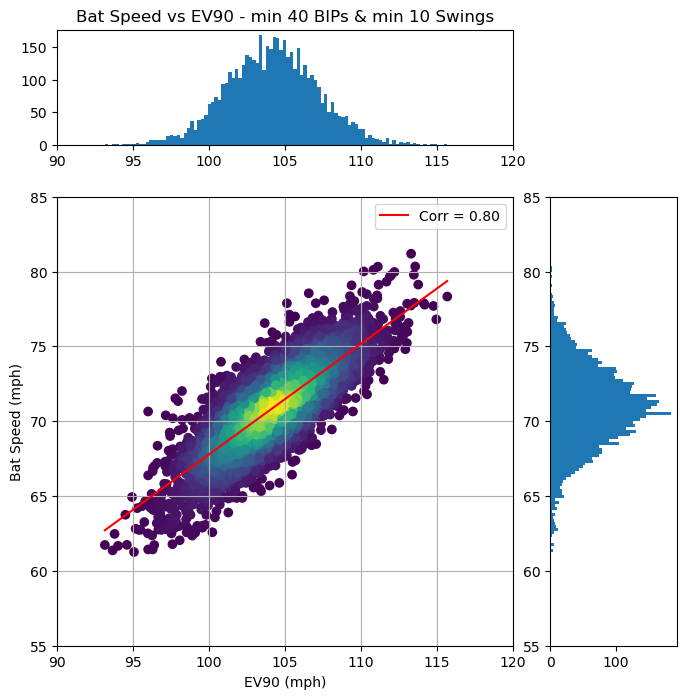

In [37]:
def draw_joint(fig, outer_cell, x, y, xlabel, ylabel, title, xlim=None, ylim=None, xticks=None, yticks=None, diag=False):
    gs = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=outer_cell, wspace=0.3, hspace=0.45)
    ax_joint = fig.add_subplot(gs[1:4, 0:3])
    ax_marg_x = fig.add_subplot(gs[0, 0:3])
    ax_marg_y = fig.add_subplot(gs[1:4, 3])

    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    ax_joint.scatter(x, y, c=density, cmap='viridis')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax_joint.plot(x_line, m * x_line + b, color='red', label=f'Corr = {np.corrcoef(x,y)[0,1]:.2f}')
    ax_joint.axline((0, 0), slope=1, color='black', linestyle='--')
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_xlim(xlim)
    ax_joint.set_ylim(ylim)
    ax_joint.set_xticks(xticks)
    ax_joint.set_yticks(yticks)
    ax_joint.set_ylabel(ylabel)
    ax_joint.legend()
    ax_joint.grid(True)
    ax_marg_x.hist(x, bins=100)
    ax_marg_y.hist(y, bins=100, orientation='horizontal')
    ax_marg_x.set_title(title)
    ax_marg_x.set_xticks(xticks)
    ax_marg_y.set_yticks(yticks)

fig = plt.figure(figsize=(8,8))
outer = gridspec.GridSpec(1, 1, figure=fig)

cd1 = grid.dropna(subset=['bat_speed', 'ev90']).copy()
cd1 = cd1.loc[(cd1['bips'] >= MIN_BIPS)&(cd1['swing_total'] >= MIN_SWINGS)]
x1, y1 = cd1['ev90'].values.astype(float), cd1['bat_speed'].values.astype(float)
draw_joint(fig, outer[0], x1, y1, 'EV90 (mph)', 'Bat Speed (mph)', f'Bat Speed vs EV90 - min {MIN_BIPS} BIPs & min {MIN_SWINGS} Swings',
           xlim = (90,120), ylim = (55,85), xticks = np.arange(90, 121, 5), yticks=np.arange(55, 86, 5)
        )

In [38]:
X = np.column_stack([np.ones(len(x1)), x1])
beta_hat = np.linalg.inv(X.T@X)@(X.T@y1)
intercept = beta_hat[0]
slope = beta_hat[1]
y_hat = X@beta_hat
resi = y1-y_hat
mse = np.mean((y1-y_hat)**2)
rss = np.sum((y1-y_hat)**2)
tss = np.sum((y1-np.mean(y1))**2)
r2 = 1-(rss/tss)
corr = np.corrcoef(x1, y1)[0, 1]

print(round(mse,2))
print(round(np.sqrt(mse),2))
print(round(r2,2))
print(round(corr,2))
print(round(corr**2,2))

2.71
1.65
0.64
0.8
0.64


To help illustrate the relationship between EV90, Imputed Bat Speed, and Observed Bat Speed, we compare their joint empirical distribution. We do filter to players that have stable exit velocities because otherwise, we would be comparing noisy estimates. Even without the Imputed Bat Speed, a player's 90th percentile Exit Velocity has a 0.81 correlation with their Bat Speed. Therefore, imputing bat speed with EV90 is likely sufficent via some modeling process.